In [1]:
import os

In [3]:
from langgraph.graph import MessagesState, StateGraph, END, START
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import tools_condition # This is the checker for the if you get a tool back
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display
from typing import Annotated, TypedDict
import operator
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

In [5]:
from langchain_groq import ChatGroq
llm = ChatGroq(model_name = "llama-3.1-8b-instant")

In [6]:
def multiply(a: int, b: int) -> int:
    """
    Multiply a and b.
    Args:
        a: first int
        b: second int
    """
    return a * b

In [7]:
def add(a: int, b: int) -> int:
    """
    Add a and b.
    Args:
        a: first int
        b: second int
    """
    return a + b

In [8]:
def divide(a: int, b: int) -> int:
    """
    Divide a and b.
    Args:
        a: first int
        b: second int
    """
    return a / b

In [10]:
search = DuckDuckGoSearchRun()

In [11]:
search.invoke("Who is current President of USA?")

'... presidents are typically viewed as leaders of their political parties, major policymaking is significantly shaped by the outcome of presidential ... baɪdən/ BY-dən; born November 20, 1942) is an American politician serving as the 46th and current president of the United States. Donald Trump is the 47th and current president of the United States, in office since January 20, 2025. ... president-elect of the United States is the ... The question, “Who is the President of the USA?”, has always been more than a matter of fact—it reflects the direction, mood, and priorities of ... In this contest for the 47th president of the US, the contrast is as wide gulf as the distance between Washington, D.C., and London, yet the race is ...'

In [12]:
tools = [add, multiply, divide, search]

In [13]:
llm_with_tools = llm.bind_tools(tools)

In [14]:
# System message
sys_msg = SystemMessage(content = "You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs. ")

In [15]:
def reasoner(state: MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

In [16]:
# Graph
builder = StateGraph(MessagesState)

# Add nodes
builder.add_node("reasoner", reasoner)
builder.add_node("tools", ToolNode(tools)) # for the tools

# Add edges
builder.add_edge(START, "reasoner")

builder.add_conditional_edges(
    "reasoner",
    # If the latest message (result) from node reasoner is a tool call -> tools_condition routes to tools
    # If the latest message (result) from node reasoner is not a tool call -> tools_condition routes

    tools_condition,
)

builder.add_edge("tools", "reasoner")
react_graph = builder.compile()

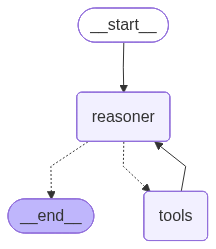

In [17]:
# Display the graph
display(Image(react_graph.get_graph(xray = True).draw_mermaid_png()))

In [18]:
messages = [HumanMessage(content = "What is 2 times of Narendra Modi's age?")]


In [19]:
messages = react_graph.invoke({"messages": messages})

In [20]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 times of Narendra Modi's age?
================================== Ai Message ==================================
Tool Calls:
  multiply (d7a4hqvc2)
 Call ID: d7a4hqvc2
  Args:
    a: 2
    b: 78
  duckduckgo_search (0wd9ekytj)
 Call ID: 0wd9ekytj
  Args:
    query: Narendra Modi age
================================= Tool Message =================================
Name: multiply

156
================================= Tool Message =================================
Name: duckduckgo_search

Narendra Damodardas Modi[a] (born 17 September 1950) is an Indian politician who has served as the prime minister of India since 2014. Age 75 years old. #2,167 Most Popular.Family life. He was the third of six children born to Damodardas Mulchand Modi. He married Jashodaben Modi in 1968. Narendra Modi is the 14th prime minister of India. His Hindu nationalist policies and some of his economic reforms have proved con

In [21]:
messages = [HumanMessage(content = "What is total of the age of Elon Musk and add height of Mount Everest in meters in musk age?")]


In [24]:
messages = react_graph.invoke({"messages": messages})

BadRequestError: Error code: 400 - {'error': {'message': "tool call validation failed: parameters for tool divide did not match schema: errors: [missing properties: 'a']", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=divide>{"b": 8848}</function>\n'}}

In [23]:
for m in messages['messages']:
    m.pretty_print()

TypeError: list indices must be integers or slices, not str

## Creating Finance Bot using Langgraph

In [26]:
import yfinance as yf

def get_stock_price(ticker: str) -> float:
    """Gets a stock price from Yahoo Finance.

    Args:
        ticker: ticker str
    """
    # This is a tool for getting the price of a stock when passed a ticker symbol
    stock = yf.Ticker(ticker)
    return stock.info['previousClose']

In [27]:
get_stock_price("AAPL")

308.82

In [28]:
# Node
def reasoner(state):
    query = state["query"]
    messages = state["messages"]
    # System message
    sys_msg = SystemMessage(content = "You are a helpful assistant tasked with using search, the yahoo ") 

    message = HumanMessage(content = query)
    messages.append(message)
    results = [llm_with_tools.invoke([sys_msg] + messages)]
    return {"messages": results}

In [29]:
tools = [add, multiply, divide, search, get_stock_price]

In [30]:
llm_with_tools = llm.bind_tools(tools)

In [31]:
class GraphState(TypedDict):
    """State of the graph"""
    query: str
    finance: str
    final_answer: str

    messages: Annotated[list[AnyMessage], operator.add]

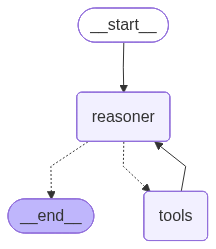

In [32]:
# Graph
workflow = StateGraph(MessagesState)

# Add Nodes
workflow.add_node("reasoner", reasoner)
workflow.add_node("tools", ToolNode(tools))

# Add Edges
workflow.add_edge(START, "reasoner")

# Conditional Edges
workflow.add_conditional_edges(
    "reasoner",
    # If the latest message (result) from node reasoner is a tool call -> tools_condition routes to tools
    # If the latest message (result) from node reasoner is not a tool call -> tools_condition routes to reasoner
    tools_condition,
)

# Normal Edges
workflow.add_edge("tools", "reasoner")

# Compile the workflow into an executable graph
react_graph = workflow.compile()

# Display the graph
display(Image(react_graph.get_graph(xray = True).draw_mermaid_png()))